In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller

ticker='NFLX'
stock=yf.Ticker(ticker)
netflix_df=stock.history(start='2000-01-01',end='2025-12-31')
netflix_df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2002-05-23 00:00:00-04:00,0.115643,0.124286,0.114571,0.119643,1047900000,0.0,0.0
2002-05-24 00:00:00-04:00,0.121429,0.122500,0.119714,0.121000,111048000,0.0,0.0
2002-05-28 00:00:00-04:00,0.121357,0.123214,0.115714,0.115714,66094000,0.0,0.0
2002-05-29 00:00:00-04:00,0.116429,0.116429,0.108571,0.110357,67578000,0.0,0.0
2002-05-30 00:00:00-04:00,0.110786,0.110786,0.107143,0.107143,101542000,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-23 00:00:00-05:00,93.400002,93.809998,91.330002,93.500000,25896200,0.0,0.0
2025-12-24 00:00:00-05:00,93.110001,93.680000,92.669998,93.639999,12427900,0.0,0.0
2025-12-26 00:00:00-05:00,93.480003,94.690002,93.269997,94.470001,22068300,0.0,0.0


In [2]:
timesteps=netflix_df.index.to_numpy() 
prices=netflix_df['Close'].to_numpy()
timesteps,prices

(array([Timestamp('2002-05-23 00:00:00-0400', tz='America/New_York'),
        Timestamp('2002-05-24 00:00:00-0400', tz='America/New_York'),
        Timestamp('2002-05-28 00:00:00-0400', tz='America/New_York'), ...,
        Timestamp('2025-12-26 00:00:00-0500', tz='America/New_York'),
        Timestamp('2025-12-29 00:00:00-0500', tz='America/New_York'),
        Timestamp('2025-12-30 00:00:00-0500', tz='America/New_York')],
       shape=(5940,), dtype=object),
 array([ 0.119643  ,  0.121     ,  0.115714  , ..., 94.47000122,
        94.15000153, 93.77999878], shape=(5940,)))

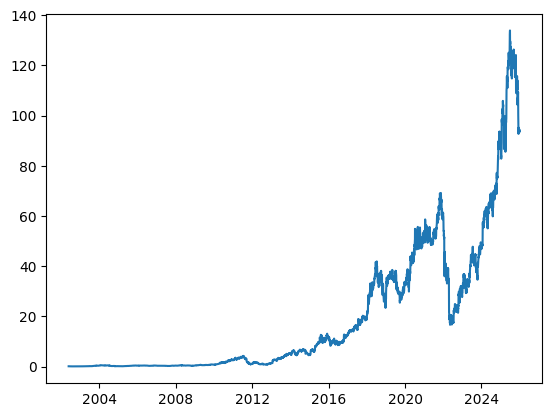

In [3]:
fig,ax=plt.subplots()
ax.plot(timesteps,prices)

In [4]:
split_1=int(0.8*len(prices))
x1,y1=timesteps[:split_1],prices[:split_1] #y1: train prices
x2,y2=timesteps[split_1:],prices[split_1:] #y2: test prices

In [5]:
adf_y1=adfuller(y1)
adf_y1 #non stationarity

(np.float64(2.6150191739031676),
 np.float64(0.9990777822567457),
 30,
 4721,
 {'1%': np.float64(-3.4317359053519567),
  '5%': np.float64(-2.862152412336451),
  '10%': np.float64(-2.567095989197428)},
 np.float64(5661.165065990603))

In [6]:
diff1_y1=np.diff(y1) #differencing of first order train
diff1_y2=np.diff(y2) #differencing of first order test
adf_diff1_y1=adfuller(diff1_y1)
adf_diff1_y1 #now the data is stationary in nature

(np.float64(-12.086005199951362),
 np.float64(2.1768510098625735e-22),
 32,
 4718,
 {'1%': np.float64(-3.431736787077574),
  '5%': np.float64(-2.8621528018679396),
  '10%': np.float64(-2.567096196561975)},
 np.float64(5639.985872815522))

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(y1.reshape(-1,1)) 

,copy,True
,with_mean,True
,with_std,True


In [8]:
scaled_y1=scaler.transform(y1.reshape(-1,1))
scaled_y2=scaler.transform(y2.reshape(-1,1))
scaled_prices=scaler.transform(prices.reshape(-1,1))
scaled_y1=scaled_y1.flatten()
scaled_y2=scaled_y2.flatten()
scaled_prices=scaled_prices.flatten()

In [9]:
scaled_y1,scaled_y2,scaled_prices

(array([-0.65229457, -0.65219894, -0.65257144, ...,  3.17659389,
         3.19392974,  3.24741663], shape=(4752,)),
 array([3.25256082, 3.23473195, 3.24142671, ..., 5.99660444, 5.97405396,
        5.94797975], shape=(1188,)),
 array([-0.65229457, -0.65219894, -0.65257144, ...,  5.99660444,
         5.97405396,  5.94797975], shape=(5940,)))

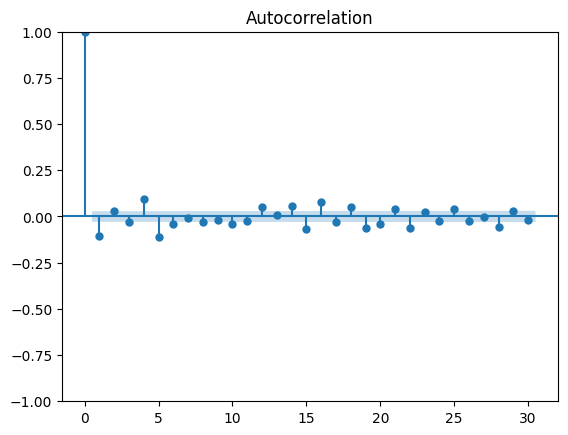

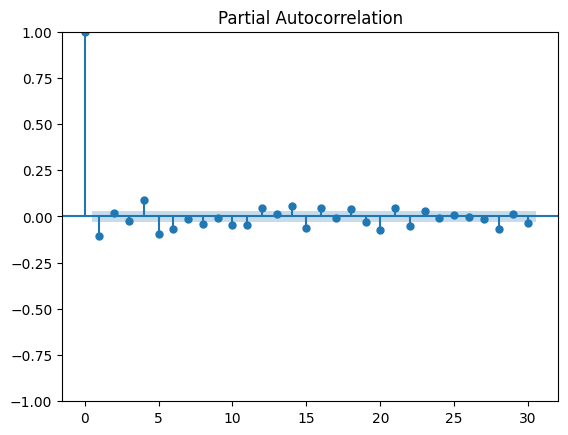

In [10]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_acf(diff1_y1,lags=30)
plot_pacf(diff1_y1,lags=30)
plt.show()

In [11]:
def mean_absolute_scaled_error(y_true,y_pred):
    y_true=tf.convert_to_tensor(y_true)
    y_pred=tf.convert_to_tensor(y_pred)
    mae=tf.reduce_mean(tf.abs(y_true-y_pred))
    mae_no_season=tf.reduce_mean(tf.abs(y_true[1:]-y_true[:-1]))
    mase=mae/mae_no_season
    return mase

In [12]:
def evaluate_metrics(y_true,y_pred):
    y_true=tf.cast(y_true,dtype=tf.float32)
    y_pred=tf.cast(y_pred,dtype=tf.float32)
    mae=tf.keras.metrics.mae(y_true,y_pred)
    rmse=tf.sqrt(tf.keras.metrics.mse(y_true,y_pred))
    mape=tf.keras.metrics.mape(y_true,y_pred)
    mase=mean_absolute_scaled_error(y_true,y_pred)

    if mae.ndim>0:
        mae=tf.reduce_mean(mae)
        rmse=tf.reduce_mean(rmse)
        mape=tf.reduce_mean(mape)
        mase=tf.reduce_mean(mase)

    return {'MAE':mae.numpy(),'RMSE':rmse.numpy(),'MAPE':mape.numpy(),'MASE':mase.numpy()} 

In [13]:
naive_forecast=y2[:-1]
y2[-10:],naive_forecast[-10:]

(array([94.56999969, 94.79000092, 94.        , 94.38999939, 93.23000336,
        93.5       , 93.63999939, 94.47000122, 94.15000153, 93.77999878]),
 array([93.76999664, 94.56999969, 94.79000092, 94.        , 94.38999939,
        93.23000336, 93.5       , 93.63999939, 94.47000122, 94.15000153]))

In [14]:
evaluate_metrics(y_true=y2[1:],y_pred=naive_forecast)

{'MAE': np.float32(0.9385097),
 'RMSE': np.float32(1.4580221),
 'MAPE': np.float32(1.7643416),
 'MASE': np.float32(0.99938446)}

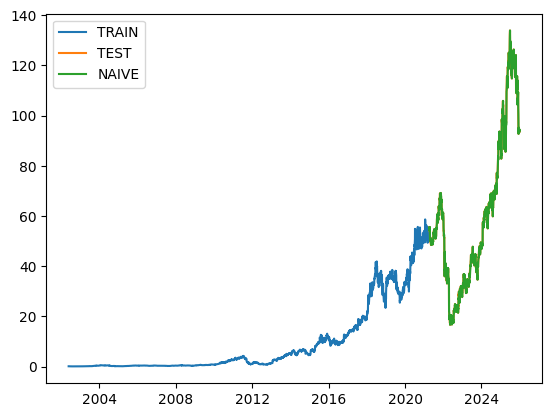

In [15]:
fig,ax=plt.subplots()
ax.plot(x1,y1)
ax.plot(x2,y2)
ax.plot(x2[1:],naive_forecast)
ax.legend(['TRAIN','TEST','NAIVE'])

In [16]:
from statsmodels.tsa.arima.model import ARIMA
arima1=ARIMA(y1,order=(1,1,1)).fit()
arima0=ARIMA(y1,order=(1,1,0)).fit()

In [17]:
arima1.aic,arima0.aic #confirms that order(1,1,1) is better fit (initial order were derived from acf,pacf plots)

(np.float64(5887.740575695598), np.float64(5906.19037089742))

In [15]:
history=[x for x in y1]
arima_predictions=[]

for t in range(len(y2)):
    model_fit=ARIMA(history,order=(1,1,1)).fit()
    yhat=model_fit.forecast()[0]
    arima_predictions.append(yhat)
    history.append(y2[t])

c:\Users\KARAN MATTOO\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [16]:
arima_results=evaluate_metrics(y_true=y2,y_pred=arima_predictions)
arima_results

{'MAE': np.float32(0.94507676),
 'RMSE': np.float32(1.4621807),
 'MAPE': np.float32(1.7768284),
 'MASE': np.float32(1.0069973)}

In [18]:
def get_labelled_window(x,horizon):
    return x[:,:-horizon],x[:,-horizon:]

In [19]:
def make_windows(x,horizon,window):
    window_step=tf.expand_dims(np.arange(window+horizon),axis=0)
    window_indices=window_step+ np.expand_dims(np.arange(len(x)-(horizon+window-1)),axis=0).T
    window_array=x[window_indices]
    window,label=get_labelled_window(window_array,horizon=horizon)
    return window,label

In [20]:
train_7_windows,train_7_labels=make_windows(y1,horizon=1,window=7)
test_7_windows,test_7_labels=make_windows(y2,horizon=1,window=7)
train_10_windows,train_10_labels=make_windows(y1,horizon=1,window=10)
test_10_windows,test_10_labels=make_windows(y2,horizon=1,window=10)
train_14_windows,train_14_labels=make_windows(y1,horizon=1,window=14)
test_14_windows,test_14_labels=make_windows(y2,horizon=1,window=14)

In [21]:
train_7_windows,train_7_labels

(array([[ 0.119643  ,  0.121     ,  0.115714  , ...,  0.107143  ,
          0.107643  ,  0.112857  ],
        [ 0.121     ,  0.115714  ,  0.110357  , ...,  0.107643  ,
          0.112857  ,  0.111786  ],
        [ 0.115714  ,  0.110357  ,  0.107143  , ...,  0.112857  ,
          0.111786  ,  0.114714  ],
        ...,
        [50.2859993 , 50.80500031, 51.39500046, ..., 52.16600037,
         53.94200134, 54.06700134],
        [50.80500031, 51.39500046, 51.3390007 , ..., 53.94200134,
         54.06700134, 54.45299911],
        [51.39500046, 51.3390007 , 52.16600037, ..., 54.06700134,
         54.45299911, 54.69900131]], shape=(4745, 7)),
 array([[ 0.111786  ],
        [ 0.114714  ],
        [ 0.118214  ],
        ...,
        [54.45299911],
        [54.69900131],
        [55.45800018]], shape=(4745, 1)))

In [22]:
from tensorflow.keras.layers import Dense,Input,LSTM,GRU,Lambda
from tensorflow.keras.losses import mae
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping
from tensorflow.keras.models import Model

In [23]:
def inverse_scale(scaled_var):
    if tf.is_tensor(scaled_var):
       scaled_var=scaled_var.numpy()
    else:
        scaled_var=np.asarray(scaled_var)   
    unscaled_var=scaler.inverse_transform(scaled_var.reshape(-1,1))
    unscaled_var=unscaled_var.flatten()
    return unscaled_var    

In [24]:
def model_preds(model,input_data):
    scaled_preds=model.predict(input_data)
    scaled_preds=tf.squeeze(scaled_preds)
    preds=inverse_scale(scaled_preds)
    return preds

In [25]:
model_1=tf.keras.Sequential([
    Dense(128,activation='relu'),
    Dense(1)
])

model_1.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
reduce_lr=ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.2,min_lr=1e-3,verbose=1)
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
model_1.fit(train_7_windows,train_7_labels,epochs=100,batch_size=64,validation_data=(test_7_windows,test_7_labels),callbacks=[reduce_lr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1914 - mae: 2.1914 - val_loss: 1.6629 - val_mae: 1.6629 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2795 - mae: 0.2795 - val_loss: 1.5428 - val_mae: 1.5428 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2740 - mae: 0.2740 - val_loss: 2.5807 - val_mae: 2.5807 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2753 - mae: 0.2753 - val_loss: 1.5827 - val_mae: 1.5827 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2517 - mae: 0.2517 - val_loss: 1.6278 - val_mae: 1.6278 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2304 - mae: 0.2304 - val_loss: 1.2436 - val_mae: 1.2436 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2254 - mae: 0.2254 - val_loss: 1.1938 - val_mae: 1.1938 - learning_rate: 0.0010
Epoch 8/100
7

In [26]:
model_1_preds=model_preds(model_1,test_7_windows)
model_1_results=evaluate_metrics(y_true=inverse_scale(tf.squeeze(test_7_labels)),y_pred=model_1_preds)
model_1_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


{'MAE': np.float32(13.748903),
 'RMSE': np.float32(21.137398),
 'MAPE': np.float32(1.7926865),
 'MASE': np.float32(1.030151)}

In [27]:
model_2=tf.keras.Sequential([
    Dense(128,activation='relu'),
    Dense(1)
])

model_2.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
reduce_lr=ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.2,min_lr=1e-3,verbose=1)
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
model_2.fit(train_10_windows,train_10_labels,epochs=100,batch_size=64,validation_data=(test_10_windows,test_10_labels),callbacks=[reduce_lr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2358 - mae: 1.2358 - val_loss: 2.0465 - val_mae: 2.0465 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2966 - mae: 0.2966 - val_loss: 2.6087 - val_mae: 2.6087 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2739 - mae: 0.2739 - val_loss: 2.8664 - val_mae: 2.8664 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2740 - mae: 0.2740 - val_loss: 1.3185 - val_mae: 1.3185 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2394 - mae: 0.2394 - val_loss: 1.2437 - val_mae: 1.2437 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2385 - mae: 0.2385 - val_loss: 2.0017 - val_mae: 2.0017 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2313 - mae: 0.2313 - val_loss: 1.2130 - val_mae: 1.2130 - learning_rate: 0.0010
Epoch 8/100
7

In [28]:
model_2_preds=model_preds(model_2,test_10_windows)
model_2_results=evaluate_metrics(y_true=inverse_scale(tf.squeeze(test_10_labels)),y_pred=model_2_preds)
model_2_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step


{'MAE': np.float32(14.127112),
 'RMSE': np.float32(21.541315),
 'MAPE': np.float32(1.8662542),
 'MASE': np.float32(1.0600021)}

In [29]:
model_3=tf.keras.Sequential([
    Dense(128,activation='relu'),
    Dense(1)
])

model_3.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
reduce_lr=ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.2,min_lr=1e-3,verbose=1)
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
model_3.fit(train_14_windows,train_14_labels,epochs=100,batch_size=64,validation_data=(test_14_windows,test_14_labels),callbacks=[reduce_lr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0430 - mae: 1.0430 - val_loss: 2.2712 - val_mae: 2.2712 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3658 - mae: 0.3658 - val_loss: 2.7920 - val_mae: 2.7920 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3541 - mae: 0.3541 - val_loss: 3.7709 - val_mae: 3.7709 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4250 - mae: 0.4250 - val_loss: 1.7774 - val_mae: 1.7774 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3204 - mae: 0.3204 - val_loss: 3.3668 - val_mae: 3.3668 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3862 - mae: 0.3862 - val_loss: 1.8589 - val_mae: 1.8589 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2995 - mae: 0.2995 - val_loss: 3.2994 - val_mae: 3.2994 - learning_rate: 0.0010
Epoch 8/100
7

In [30]:
model_3_preds=model_preds(model_3,test_14_windows)
model_3_results=evaluate_metrics(y_true=inverse_scale(tf.squeeze(test_14_labels)),y_pred=model_3_preds)
model_3_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


{'MAE': np.float32(14.288853),
 'RMSE': np.float32(21.660595),
 'MAPE': np.float32(1.8802809),
 'MASE': np.float32(1.0697476)}

In [31]:
#the above models demonstrate that 7 day window and 10 day window work better while 7 day window performing the best among them

In [32]:
model_uni_lstm1=tf.keras.Sequential([
    Lambda(lambda x: tf.expand_dims(x,axis=-1)),
    LSTM(32,activation='relu',recurrent_dropout=0.2,return_sequences=True),
    LSTM(32,activation='relu',recurrent_dropout=0.2),
    Dense(1)
])


model_uni_lstm1.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
reduce_lr=ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.2,min_lr=1e-5,verbose=1)
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
model_uni_lstm1.fit(train_7_windows,train_7_labels,epochs=100,batch_size=64,validation_data=(test_7_windows,test_7_labels),callbacks=[reduce_lr,early_stop])

Epoch 1/100

75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.3794 - mae: 3.3794 - val_loss: 7.2306 - val_mae: 7.2306 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8622 - mae: 0.8622 - val_loss: 4.9758 - val_mae: 4.9758 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6152 - mae: 0.6152 - val_loss: 4.9620 - val_mae: 4.9620 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5195 - mae: 0.5195 - val_loss: 4.4687 - val_mae: 4.4687 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4685 - mae: 0.4685 - val_loss: 6.1455 - val_mae: 6.1455 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4632 - mae: 0.4632 - val_loss: 5.1230 - val_mae: 5.1230 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4316 - mae: 0.4316 - val_loss: 4.4902 - val_mae: 4.4902 - learning_rate: 0.0010
Epoch 8/100


In [33]:
model_uni_lstm1_preds=model_preds(model_uni_lstm1,test_7_windows)
model_uni_lstm1_results=evaluate_metrics(y_true=inverse_scale(tf.squeeze(test_7_labels)),y_pred=model_uni_lstm1_preds)
model_uni_lstm1_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


{'MAE': np.float32(40.04675),
 'RMSE': np.float32(51.17405),
 'MAPE': np.float32(5.0769114),
 'MASE': np.float32(3.0005448)}

In [34]:
model_uni_lstm2=tf.keras.Sequential([
    Lambda(lambda x: tf.expand_dims(x,axis=-1)),
    LSTM(32,activation='tanh',return_sequences=True,recurrent_dropout=0.2),
    LSTM(32,activation='tanh',recurrent_dropout=0.2),
    Dense(1)
])


model_uni_lstm2.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
reduce_lr=ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.2,min_lr=1e-5,verbose=1)
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
model_uni_lstm2.fit(train_7_windows,train_7_labels,epochs=100,batch_size=64,validation_data=(test_7_windows,test_7_labels),callbacks=[reduce_lr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 7.4985 - mae: 7.4985 - val_loss: 52.0800 - val_mae: 52.0800 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2871 - mae: 5.2871 - val_loss: 48.4114 - val_mae: 48.4114 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.6061 - mae: 4.6061 - val_loss: 46.0098 - val_mae: 46.0098 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1229 - mae: 4.1229 - val_loss: 43.8384 - val_mae: 43.8384 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6819 - mae: 3.6819 - val_loss: 41.7953 - val_mae: 41.7953 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3155 - mae: 3.3155 - val_loss: 39.9451 - val_mae: 39.9451 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9703 - mae: 2.9703 - val_loss: 38.1695 - val_mae: 38.1695 - learning_rate: 0.0010

In [35]:
model_uni_lstm2_preds=model_preds(model_uni_lstm2,test_7_windows)
model_uni_lstm2_results=evaluate_metrics(y_true=inverse_scale(tf.squeeze(test_7_labels)),y_pred=model_uni_lstm2_preds)
model_uni_lstm2_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


{'MAE': np.float32(212.31543),
 'RMSE': np.float32(376.30347),
 'MAPE': np.float32(15.837812),
 'MASE': np.float32(15.907957)}

In [36]:
netflix_price_df=pd.DataFrame({'Close':prices},index=timesteps)
netflix_price_df

,Close
2002-05-23 00:00:00-04:00,0.119643
2002-05-24 00:00:00-04:00,0.121000
2002-05-28 00:00:00-04:00,0.115714
2002-05-29 00:00:00-04:00,0.110357
2002-05-30 00:00:00-04:00,0.107143
...,...
2025-12-23 00:00:00-05:00,93.500000
2025-12-24 00:00:00-05:00,93.639999
2025-12-26 00:00:00-05:00,94.470001
2025-12-29 00:00:00-05:00,94.150002


In [37]:
netflix_price_df['ema_20']=ema_20=netflix_price_df['Close'].ewm(span=20,adjust=False).mean()
ema_12=netflix_price_df['Close'].ewm(span=12,adjust=False).mean()
ema_26=netflix_price_df['Close'].ewm(span=26,adjust=False).mean()
macd=ema_12-ema_26
signal_line=macd.ewm(span=9,adjust=False).mean()
netflix_price_df['MACD Histogram']=macd-signal_line
netflix_price_df


,Close,ema_20,MACD Histogram
2002-05-23 00:00:00-04:00,0.119643,0.119643,0.000000
2002-05-24 00:00:00-04:00,0.121000,0.119772,0.000087
2002-05-28 00:00:00-04:00,0.115714,0.119386,-0.000201
2002-05-29 00:00:00-04:00,0.110357,0.118526,-0.000713
2002-05-30 00:00:00-04:00,0.107143,0.117442,-0.001199
...,...,...,...
2025-12-23 00:00:00-05:00,93.500000,98.314140,-0.003673
2025-12-24 00:00:00-05:00,93.639999,97.868983,0.118508
2025-12-26 00:00:00-05:00,94.470001,97.545271,0.280869
2025-12-29 00:00:00-05:00,94.150002,97.221912,0.385871


In [38]:
netflix_multi_df=netflix_price_df.copy()
for i in range(7):
    netflix_multi_df[f'Close {i+1}']=netflix_multi_df['Close'].shift(periods=i+1)
    netflix_multi_df[f'ema_20 {i+1}']=netflix_multi_df['ema_20'].shift(periods=i+1)
    netflix_multi_df[f'MACD Histogram {i+1}']=netflix_multi_df['MACD Histogram'].shift(periods=i+1)

netflix_multi_df=netflix_multi_df.dropna()
netflix_multi_df

,Close,ema_20,MACD Histogram,Close 1,ema_20 1,MACD Histogram 1,Close 2,ema_20 2,MACD Histogram 2,Close 3,...,MACD Histogram 4,Close 5,ema_20 5,MACD Histogram 5,Close 6,ema_20 6,MACD Histogram 6,Close 7,ema_20 7,MACD Histogram 7
2002-06-04 00:00:00-04:00,0.111786,0.115744,-0.000940,0.112857,0.116161,-0.001119,0.107643,0.116509,-0.001405,0.107143,...,-0.000713,0.115714,0.119386,-0.000201,0.121000,0.119772,0.000087,0.119643,0.119643,0.000000
2002-06-05 00:00:00-04:00,0.114714,0.115646,-0.000578,0.111786,0.115744,-0.000940,0.112857,0.116161,-0.001119,0.107643,...,-0.001199,0.110357,0.118526,-0.000713,0.115714,0.119386,-0.000201,0.121000,0.119772,0.000087
2002-06-06 00:00:00-04:00,0.118214,0.115891,-0.000085,0.114714,0.115646,-0.000578,0.111786,0.115744,-0.000940,0.112857,...,-0.001405,0.107143,0.117442,-0.001199,0.110357,0.118526,-0.000713,0.115714,0.119386,-0.000201
2002-06-07 00:00:00-04:00,0.111857,0.115506,-0.000162,0.118214,0.115891,-0.000085,0.114714,0.115646,-0.000578,0.111786,...,-0.001119,0.107643,0.116509,-0.001405,0.107143,0.117442,-0.001199,0.110357,0.118526,-0.000713
2002-06-10 00:00:00-04:00,0.115643,0.115519,0.000054,0.111857,0.115506,-0.000162,0.118214,0.115891,-0.000085,0.114714,...,-0.000940,0.112857,0.116161,-0.001119,0.107643,0.116509,-0.001405,0.107143,0.117442,-0.001199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23 00:00:00-05:00,93.500000,98.314140,-0.003673,93.230003,98.820891,-0.121354,94.389999,99.409406,-0.208791,94.000000,...,-0.537023,94.570000,101.170454,-0.752303,93.769997,101.865239,-0.952334,95.190002,102.717370,-1.054987
2025-12-24 00:00:00-05:00,93.639999,97.868983,0.118508,93.500000,98.314140,-0.003673,93.230003,98.820891,-0.121354,94.389999,...,-0.386702,94.790001,100.562792,-0.537023,94.570000,101.170454,-0.752303,93.769997,101.865239,-0.952334
2025-12-26 00:00:00-05:00,94.470001,97.545271,0.280869,93.639999,97.868983,0.118508,93.500000,98.314140,-0.003673,93.230003,...,-0.208791,94.000000,99.937764,-0.386702,94.790001,100.562792,-0.537023,94.570000,101.170454,-0.752303
2025-12-29 00:00:00-05:00,94.150002,97.221912,0.385871,94.470001,97.545271,0.280869,93.639999,97.868983,0.118508,93.500000,...,-0.121354,94.389999,99.409406,-0.208791,94.000000,99.937764,-0.386702,94.790001,100.562792,-0.537023


In [39]:
input_cols=['Close 1', 'ema_20 1',
       'MACD Histogram 1', 'Close 2', 'ema_20 2', 'MACD Histogram 2',
       'Close 3', 'ema_20 3', 'MACD Histogram 3', 'Close 4', 'ema_20 4',
       'MACD Histogram 4', 'Close 5', 'ema_20 5', 'MACD Histogram 5',
       'Close 6', 'ema_20 6', 'MACD Histogram 6', 'Close 7', 'ema_20 7',
       'MACD Histogram 7']
target_col='Close'
input_df=netflix_multi_df[input_cols]
target=netflix_multi_df[target_col]

In [40]:
split_2=int(0.8 *len(netflix_multi_df['Close 1']))
train_inputs,train_target=input_df.iloc[:split_2,:],target[:split_2]
test_inputs,test_target=input_df.iloc[split_2:,:],target[split_2:]

In [41]:
scaler_multi_input=StandardScaler()
scaler_multi_input.fit(train_inputs)

,copy,True
,with_mean,True
,with_std,True


In [42]:
train_inputs=scaler_multi_input.transform(train_inputs)
test_inputs=scaler_multi_input.transform(test_inputs)

In [43]:
scaler_multi_target=StandardScaler()
scaler_multi_target.fit(train_target.to_numpy().reshape(-1,1))

,copy,True
,with_mean,True
,with_std,True


In [44]:
train_target=scaler_multi_target.transform(train_target.to_numpy().reshape(-1,1))
test_target=scaler_multi_target.transform(test_target.to_numpy().reshape(-1,1))
train_target=train_target.flatten()
test_target=test_target.flatten()

In [46]:
def model_multi_preds(model,input_data):
    preds=model.predict(input_data)
    preds=scaler_multi_target.inverse_transform(preds.reshape(-1,1))
    preds=preds.flatten()
    return tf.squeeze(preds)

In [49]:
def inverse_multi_scale(scaled_var):
    if tf.is_tensor(scaled_var):
        scaled_var=scaled_var.to_numpy()
    else:
        scaled_var=np.asarray(scaled_var)

    unscaled_var=scaler_multi_target.inverse_transform(scaled_var.reshape(-1,1))
    unscaled_var=unscaled_var.flatten()
    return unscaled_var        

In [45]:
model_3_lstm=tf.keras.Sequential([
    Lambda(lambda x: tf.reshape(x,shape=[-1,7,3])),
    LSTM(32,activation='relu',return_sequences=True,recurrent_dropout=0.2),
    LSTM(32,activation='relu',recurrent_dropout=0.2),
    Dense(1)
])


model_3_lstm.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
reduce_lr=ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.2,min_lr=1e-6,verbose=1)
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
model_3_lstm.fit(train_inputs,train_target,epochs=100,batch_size=64,validation_data=(test_inputs,test_target),callbacks=[reduce_lr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3380 - mae: 0.3380 - val_loss: 0.7439 - val_mae: 0.7439 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0531 - mae: 0.0531 - val_loss: 0.2095 - val_mae: 0.2095 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0399 - mae: 0.0399 - val_loss: 0.4022 - val_mae: 0.4022 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0338 - mae: 0.0338 - val_loss: 0.2541 - val_mae: 0.2541 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0289 - mae: 0.0289 - val_loss: 0.2201 - val_mae: 0.2201 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0289 - mae: 0.0289 - val_loss: 0.2011 - val_mae: 0.2011 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0280 - mae: 0.0280 - val_loss: 0.1859 - val_mae: 0.1859 - learning_rate: 0.0010
Epoch 8/100
7

In [50]:
model_3_results=evaluate_metrics(y_true=inverse_multi_scale(test_target),y_pred=model_3_preds)
model_3_results

{'MAE': np.float32(2.3198535),
 'RMSE': np.float32(3.4730093),
 'MAPE': np.float32(4.445596),
 'MASE': np.float32(2.4703267)}

In [51]:
model_4=tf.keras.Sequential([
    Dense(128,activation='relu'),
    Dense(1)
])
model_4.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
reduce_lr=ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.2,min_lr=1e-5,verbose=1)
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
model_4.fit(train_inputs,train_target,epochs=100,batch_size=64,validation_data=(test_inputs,test_target),callbacks=[reduce_lr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0943 - mae: 0.0943 - val_loss: 0.2578 - val_mae: 0.2578 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0297 - mae: 0.0297 - val_loss: 0.1621 - val_mae: 0.1621 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0252 - mae: 0.0252 - val_loss: 0.1626 - val_mae: 0.1626 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0273 - mae: 0.0273 - val_loss: 0.1104 - val_mae: 0.1104 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0214 - mae: 0.0214 - val_loss: 0.1112 - val_mae: 0.1112 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0213 - mae: 0.0213 - val_loss: 0.1168 - val_mae: 0.1168 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0215 - mae: 0.0215 - val_loss: 0.1099 - val_mae: 0.1099 - learning_rate: 0.0010
Epoch 8/100
7

In [52]:
model_4_preds=model_preds(model_4,test_inputs)
model_4_results=evaluate_metrics(y_true=inverse_multi_scale(test_target),y_pred=model_4_preds)
model_4_results

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step


{'MAE': np.float32(1.1055942),
 'RMSE': np.float32(1.6372135),
 'MAPE': np.float32(2.166023),
 'MASE': np.float32(1.1773065)}